# Análise Completa do Framework de Representação Ortogonal (F1)

Este notebook consolida uma análise ponta a ponta do trabalho, cobrindo:

1. **Desempenho dos modelos** com evolução de loss e AUROC.
2. **Separação linear e não linear** entre representações de piloto e equipe.
3. **Atribuição SHAP por bloco latente** (piloto, equipe, pista) no duelo MAX vs LEWIS em 2021.
4. **Análise sazonal completa de 2021** para todos os pilotos, com índices de habilidade e dependência da equipe.
5. **Estudo contrafactual**: e se RUSSELL estivesse no lugar de BOTTAS em 2021?
6. **Aplicação prática**: suporte à decisão de line-up piloto-equipe.

As seções usam os artefatos locais do projeto (`training_results.json`, modelos `.pth`, `instances.csv` e mapeamentos por temporada).

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from IPython.display import display

sys.path.append(os.path.abspath("src"))

from train import prepare_data_and_graph, hsic_rbf
from models.pipeline_fusion import F1OrthogonalPipeline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# Configuracoes globais da analise
ANALYSIS_YEAR = 2021
ANALYSIS_ROUND = 22  # Abu Dhabi
DUEL_DRIVERS = ("VER", "HAM")
COUNTERFACTUAL_DRIVERS = ("BOT", "RUS")
BACKGROUND_SIZE = 50

DRIVER_FEATURES = [
    "avg_qualifying_pos",
    "teammate_delta",
    "crash_rate",
    "podium_rate",
    "experience",
    "points_per_finish",
]
TRACK_FEATURES = [
    "altitude_m",
    "length_m",
    "corners_count",
    "rotation",
    "avg_track_temp",
]

ROOT = Path(".")
TRAINING_RESULTS_PATH = ROOT / "output/models/training_results.json"
INSTANCES_PATH = ROOT / "output/dataset/instances.csv"
MAPPINGS_PATH_TEMPLATE = ROOT / "output/data/mappings/mappings_{year}.json"
MODELS_DIR = ROOT / "output/models"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device em uso: {device}")


_graph_cache = None
_loader_cache = None
_model_cache = {}


def load_training_results(path=TRAINING_RESULTS_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {path}")
    with open(path, "r") as f:
        return json.load(f)


def results_by_name(results):
    return {row.get("model_name"): row for row in results}


def get_model_names(results):
    names = [row.get("model_name") for row in results if row.get("model_name")]
    return [name for name in names if (MODELS_DIR / f"{name}.pth").exists()]


def load_mappings(year=ANALYSIS_YEAR):
    path = Path(str(MAPPINGS_PATH_TEMPLATE).format(year=year))
    if not path.exists():
        raise FileNotFoundError(f"Mapeamento nao encontrado: {path}")
    with open(path, "r") as f:
        return json.load(f)


def load_instances(path=INSTANCES_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {path}")
    return pd.read_csv(path)


def get_driver_id(mappings, abbr):
    abbr = abbr.upper()
    if abbr not in mappings["drivers"]:
        available = ", ".join(sorted(mappings["drivers"].keys())[:12])
        raise KeyError(f"Piloto {abbr} nao encontrado. Exemplos disponiveis: {available}")
    return int(mappings["drivers"][abbr]["driver_id"])


def get_driver_name(mappings, abbr):
    return mappings["drivers"][abbr.upper()]["name"]


def get_race_name(mappings, round_id):
    for event_name, info in mappings["circuits"].items():
        if int(info["round"]) == int(round_id):
            return event_name
    return f"Round {round_id}"


def get_graph_and_test_loader():
    global _graph_cache, _loader_cache
    if _graph_cache is None or _loader_cache is None:
        _, _, test_loader, graph_data = prepare_data_and_graph()
        _graph_cache = graph_data.to(device)
        _loader_cache = test_loader
    return _loader_cache, _graph_cache


def load_model(model_name, config=None, force_reload=False):
    key = (model_name, force_reload)
    if key in _model_cache and not force_reload:
        return _model_cache[key]

    test_loader, graph_data = get_graph_and_test_loader()
    del test_loader

    config = config or {}
    latent_dim = int(config.get("latent_dim", 8))
    use_track_encoder = bool(config.get("use_track_encoder", True))

    num_nodes_dict = {nt: graph_data[nt].num_nodes for nt in graph_data.node_types}
    model = F1OrthogonalPipeline(
        num_nodes_dict=num_nodes_dict,
        latent_dim=latent_dim,
        use_track_encoder=use_track_encoder,
    ).to(device)

    model_path = MODELS_DIR / f"{model_name}.pth"
    if not model_path.exists():
        raise FileNotFoundError(f"Checkpoint nao encontrado: {model_path}")

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    _model_cache[key] = model
    return model


def get_instance_row(df_instances, year, round_id, driver_id):
    race_df = df_instances[(df_instances["year"] == year) & (df_instances["round"] == round_id)]
    row_df = race_df[race_df["driverId"] == driver_id]
    if row_df.empty:
        raise ValueError(
            f"Nenhuma linha encontrada para year={year}, round={round_id}, driverId={driver_id}"
        )
    return row_df.iloc[0], race_df


def get_instance_tensors(row):
    x_d = torch.tensor(row[DRIVER_FEATURES].astype(float).values, dtype=torch.float32).unsqueeze(0).to(device)
    x_t = torch.tensor(row[TRACK_FEATURES].astype(float).values, dtype=torch.float32).unsqueeze(0).to(device)
    c_id = torch.tensor([int(row["constructorId"])], dtype=torch.long).to(device)
    return x_d, x_t, c_id


def forward_probability(model, x_d, x_t, c_id, graph_data):
    with torch.no_grad():
        logits, _, _, _, _ = model(
            x_driver=x_d,
            x_track=x_t,
            graph_x_dict=graph_data.x_dict,
            graph_edge_index_dict=graph_data.edge_index_dict,
            target_constructor_ids=c_id,
        )
        return torch.sigmoid(logits).squeeze().item()


def get_fused_vector(model, x_d, x_t, c_id, graph_data):
    with torch.no_grad():
        v_driver = model.driver_encoder(x_d)
        v_team = model.team_encoder(graph_data.x_dict, graph_data.edge_index_dict, c_id)
        if model.use_track_encoder:
            v_track = model.track_encoder(x_t)
            return torch.cat([v_driver, v_team, v_track], dim=-1)
        return torch.cat([v_driver, v_team], dim=-1)


def summarize_block_impacts(shap_vector, model):
    latent_dim = int(shap_vector.shape[0] // (3 if model.use_track_encoder else 2))
    abs_shap = np.abs(shap_vector)

    pilot_impact = np.sum(abs_shap[0:latent_dim])
    team_impact = np.sum(abs_shap[latent_dim : 2 * latent_dim])

    if model.use_track_encoder:
        track_impact = np.sum(abs_shap[2 * latent_dim : 3 * latent_dim])
    else:
        track_impact = 0.0

    total = pilot_impact + team_impact + track_impact
    if total <= 1e-12:
        return {
            "pilot_abs": pilot_impact,
            "team_abs": team_impact,
            "track_abs": track_impact,
            "pilot_share": 0.0,
            "team_share": 0.0,
            "track_share": 0.0,
        }

    return {
        "pilot_abs": pilot_impact,
        "team_abs": team_impact,
        "track_abs": track_impact,
        "pilot_share": 100.0 * pilot_impact / total,
        "team_share": 100.0 * team_impact / total,
        "track_share": 100.0 * track_impact / total,
    }


def model_prediction_fn(model):
    def _predict_from_fused(x_np):
        x = torch.tensor(x_np, dtype=torch.float32, device=device)
        with torch.no_grad():
            y = torch.sigmoid(model.classifier(x)).detach().cpu().numpy().reshape(-1)
        return y

    return _predict_from_fused


print("Setup concluido.")

c:\Users\tonim\OneDrive\Área de Trabalho\UFMG\F1\POC I\ortogonal-representation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device em uso: cpu
Setup concluido.


## 1) Desempenho dos Diferentes Tipos de Modelo

Nesta seção comparamos os modelos treinados no projeto, analisando:

- evolução de `train_loss` e `val_loss`;
- evolução de `val_auroc`;
- comparação final de métricas de teste.

Quando houver ablações no `training_results.json`, elas entram automaticamente na análise.

Modelos disponiveis: ['model_orthogonal', 'model_no_orthogonal', 'model_ablation_p01_c01', 'model_ablation_p1_c01', 'model_ablation_p1_c1']

Tabela de metricas finais (teste):


,model_name,lambda_pairwise,lambda_crossdim,use_track_encoder,test_loss,test_bce,test_orth,test_crossdim,test_hsic,test_auroc
0,model_orthogonal,1.0,0.0,True,0.672991,0.324645,0.010676,0.455954,0.049545,0.849560
1,model_no_orthogonal,0.0,0.0,True,0.659854,0.326915,0.466654,0.514038,0.058083,0.841447
3,model_ablation_p1_c01,1.0,0.1,True,0.704421,0.321270,0.016280,0.427435,0.060589,0.832646
2,model_ablation_p01_c01,0.1,0.1,True,0.702609,0.328183,0.042029,0.427042,0.062256,0.832233
4,model_ablation_p1_c1,1.0,1.0,True,1.136792,0.388930,0.018069,0.343050,0.025145,0.697607


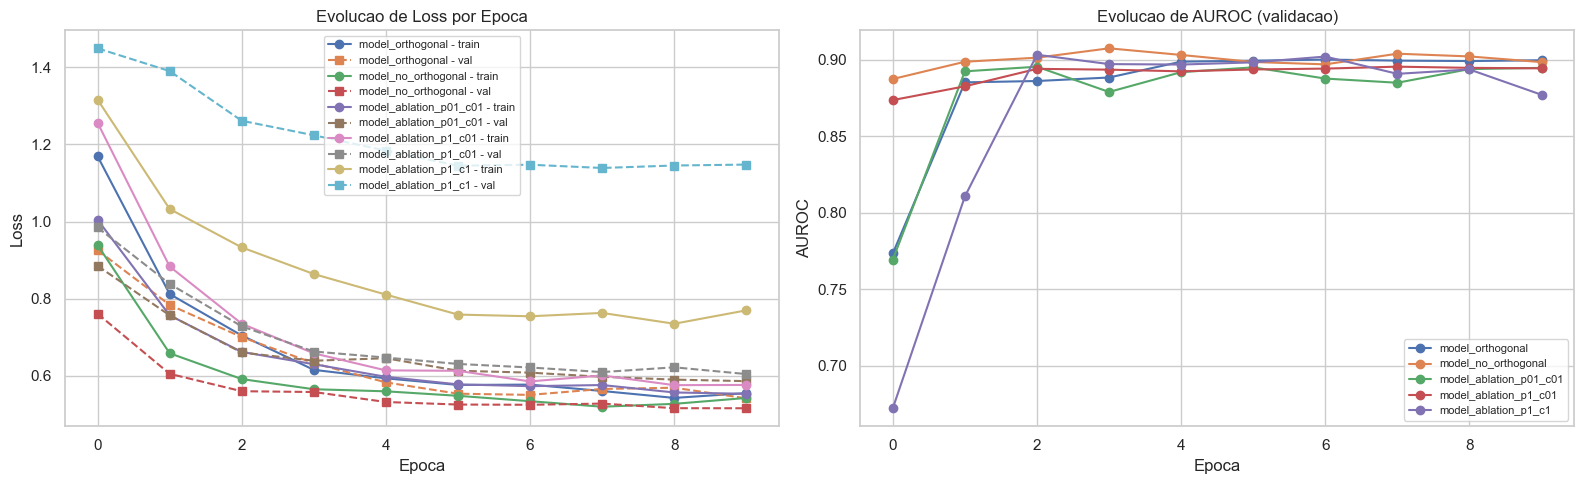

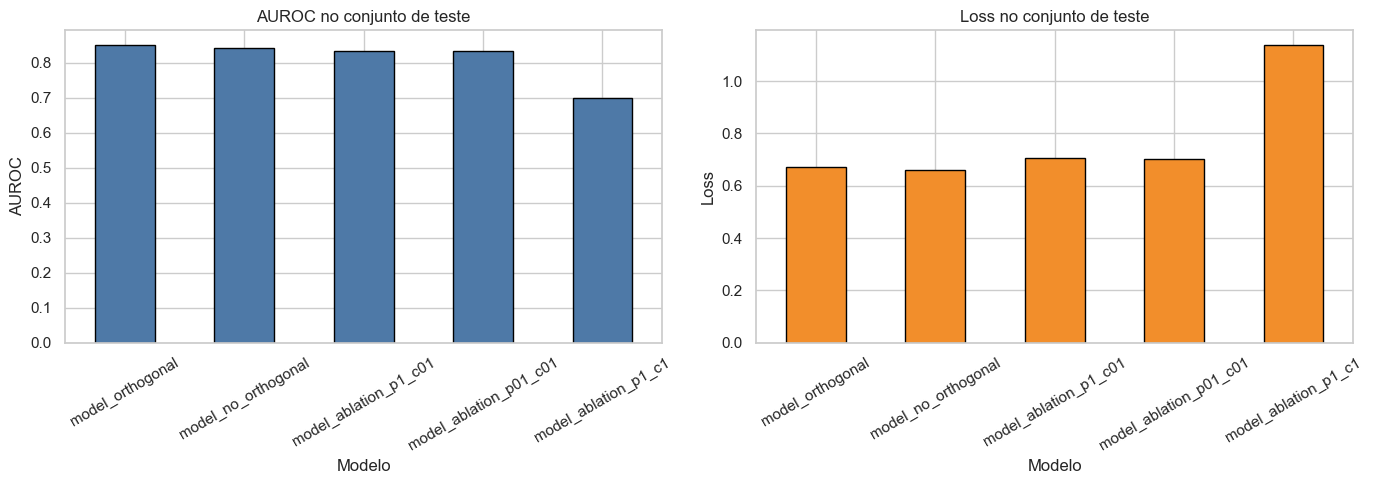

In [2]:
results = load_training_results()
results_map = results_by_name(results)
available_model_names = get_model_names(results)

if not available_model_names:
    raise RuntimeError("Nenhum modelo com checkpoint .pth encontrado em output/models")

print("Modelos disponiveis:", available_model_names)

# Tabela final de metricas de teste
rows = []
for model_name in available_model_names:
    row = results_map[model_name]
    cfg = row.get("configuration", {})
    test = row.get("test_metrics", {})
    rows.append(
        {
            "model_name": model_name,
            "lambda_pairwise": cfg.get("lambda_pairwise", cfg.get("lambda_orthogonal", np.nan)),
            "lambda_crossdim": cfg.get("lambda_crossdim", np.nan),
            "use_track_encoder": cfg.get("use_track_encoder", True),
            "test_loss": test.get("loss", np.nan),
            "test_bce": test.get("bce", np.nan),
            "test_orth": test.get("orth", np.nan),
            "test_crossdim": test.get("crossdim", np.nan),
            "test_hsic": test.get("hsic", np.nan),
            "test_auroc": test.get("auroc", np.nan),
        }
    )

metrics_df = pd.DataFrame(rows).sort_values("test_auroc", ascending=False)
print("\nTabela de metricas finais (teste):")
display(metrics_df)

# Curvas de treino/validacao
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for model_name in available_model_names:
    history = results_map[model_name].get("history", {})
    if history.get("train_loss"):
        axes[0].plot(history["train_loss"], marker="o", label=f"{model_name} - train")
    if history.get("val_loss"):
        axes[0].plot(history["val_loss"], marker="s", linestyle="--", label=f"{model_name} - val")

axes[0].set_title("Evolucao de Loss por Epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

for model_name in available_model_names:
    history = results_map[model_name].get("history", {})
    if history.get("val_auroc"):
        axes[1].plot(history["val_auroc"], marker="o", label=model_name)

axes[1].set_title("Evolucao de AUROC (validacao)")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("AUROC")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Comparacao final em barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = metrics_df.set_index("model_name")
plot_df["test_auroc"].plot(kind="bar", ax=axes[0], color="#4e79a7", edgecolor="black")
axes[0].set_title("AUROC no conjunto de teste")
axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("AUROC")
axes[0].tick_params(axis="x", rotation=30)

plot_df["test_loss"].plot(kind="bar", ax=axes[1], color="#f28e2b", edgecolor="black")
axes[1].set_title("Loss no conjunto de teste")
axes[1].set_xlabel("Modelo")
axes[1].set_ylabel("Loss")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 2) Separação Linear e Não Linear

A análise de não linearidade combina três visões:

1. **Ortogonalidade alinhada ao treino**: distribuição de `|cos(V_piloto, V_equipe)|`.
2. **Acoplamento dimensão-a-dimensão**: heatmap de `|corr|` entre dimensões latentes.
3. **Dependência não linear**: HSIC-RBF por batch no teste, além de histórico `train_hsic/val_hsic` quando disponível.

Isso permite separar o efeito de desacoplamento linear do efeito de dependência estatística não linear.

-> Carregando Grafo do RelBench...
Loading Database object from C:\Users\tonim\AppData\Local\relbench\relbench\Cache/rel-f1/db...
Done in 0.22 seconds.
-> Carregando e Alinhando CSV Tabular...
-> Train: 1608, Val: 438, Test: 238
Estatisticas de ortogonalidade por modelo:


,model_name,mean_abs_cos,median_abs_cos,p95_abs_cos,pct_abs_cos_lt_01,test_hsic_batch_mean,test_hsic_batch_std
0,model_orthogonal,0.010898,0.007127,0.029871,100.000000,0.049545,0.020387
1,model_no_orthogonal,0.466693,0.454527,0.662636,2.521008,0.058083,0.015239


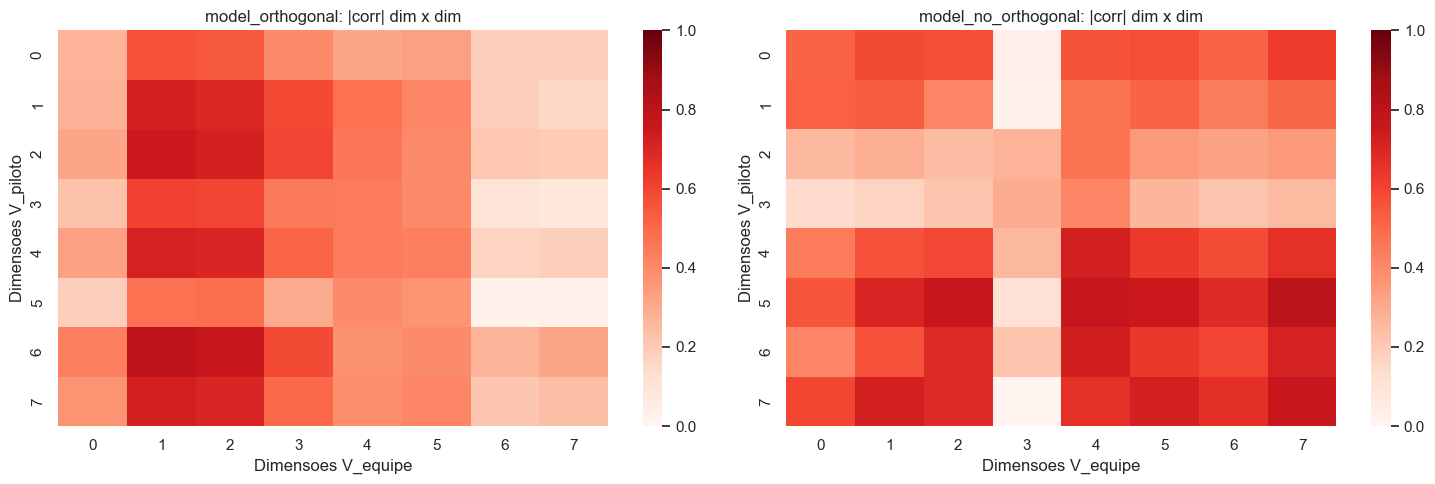

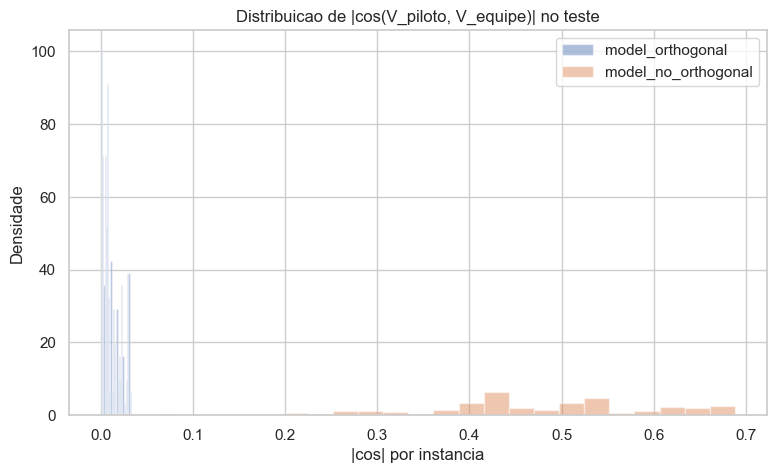

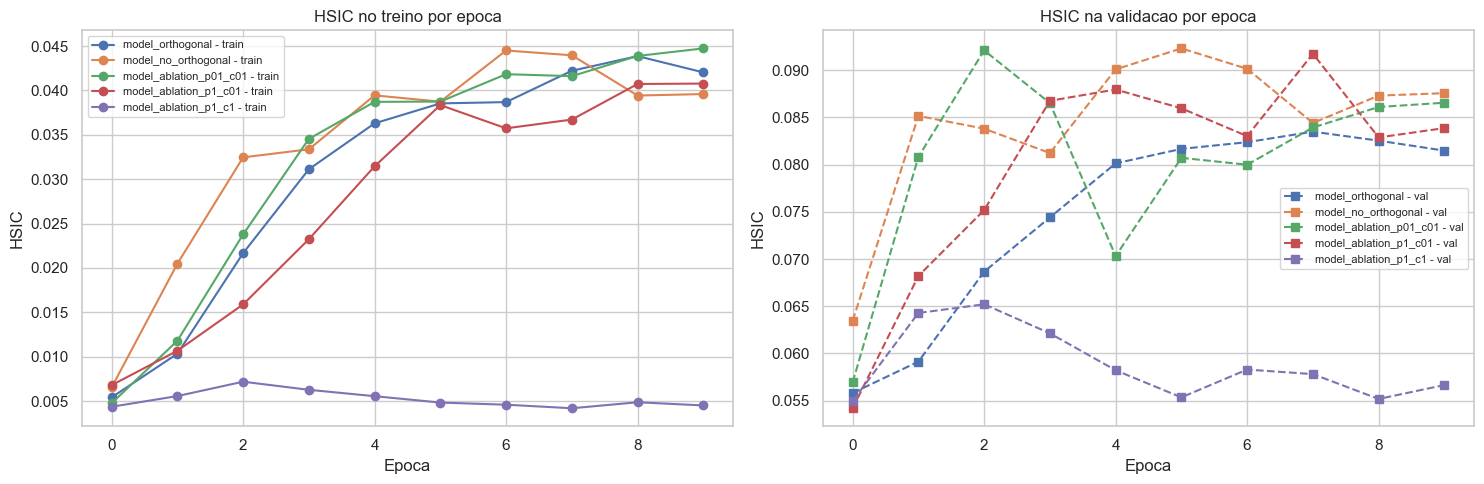

,model_name,test_hsic,test_auroc
4,model_ablation_p1_c1,0.025145,0.697607
0,model_orthogonal,0.049545,0.849560
1,model_no_orthogonal,0.058083,0.841447
3,model_ablation_p1_c01,0.060589,0.832646
2,model_ablation_p01_c01,0.062256,0.832233


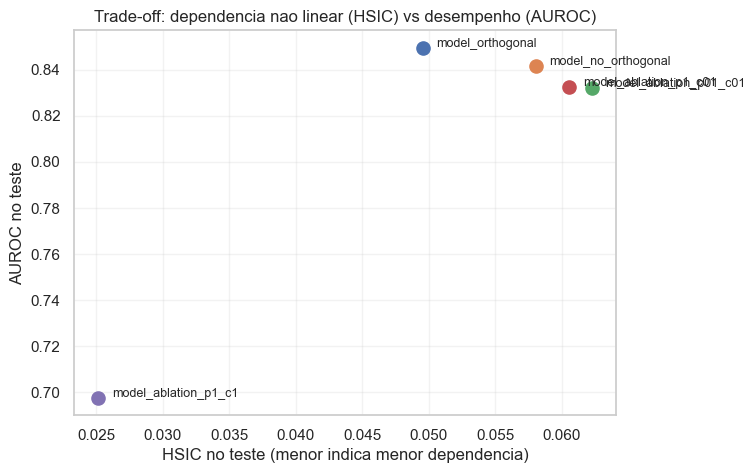

In [3]:
def pairwise_abs_cosine_stats(v_p_tensor, v_e_tensor):
    v_p_norm = F.normalize(v_p_tensor, p=2, dim=-1)
    v_e_norm = F.normalize(v_e_tensor, p=2, dim=-1)
    abs_cos = torch.abs(torch.sum(v_p_norm * v_e_norm, dim=-1))
    return {
        "mean_abs_cos": abs_cos.mean().item(),
        "median_abs_cos": abs_cos.median().item(),
        "p95_abs_cos": torch.quantile(abs_cos, q=0.95).item(),
        "pct_abs_cos_lt_01": (abs_cos < 0.1).float().mean().item() * 100.0,
    }, abs_cos.cpu().numpy()


def calc_cross_dim_matrix(v_p_tensor, v_e_tensor):
    eps = 1e-8
    v_p_center = v_p_tensor - v_p_tensor.mean(dim=0, keepdim=True)
    v_e_center = v_e_tensor - v_e_tensor.mean(dim=0, keepdim=True)
    v_p_std = v_p_center / (v_p_center.std(dim=0, keepdim=True) + eps)
    v_e_std = v_e_center / (v_e_center.std(dim=0, keepdim=True) + eps)
    n = v_p_std.shape[0]
    cross_corr = torch.matmul(v_p_std.T, v_e_std) / max(n - 1, 1)
    return torch.abs(cross_corr).cpu().numpy()


def collect_latent_and_hsic(model_name):
    result = results_map[model_name]
    model = load_model(model_name, result.get("configuration", {}))
    test_loader, graph_data = get_graph_and_test_loader()

    all_v_driver = []
    all_v_team = []
    hsic_values = []

    with torch.no_grad():
        for batch in test_loader:
            x_driver, x_track, target_constructor_ids, _ = [b.to(device) for b in batch]
            _, _, _, v_driver, v_team = model(
                x_driver=x_driver,
                x_track=x_track,
                graph_x_dict=graph_data.x_dict,
                graph_edge_index_dict=graph_data.edge_index_dict,
                target_constructor_ids=target_constructor_ids,
            )
            all_v_driver.append(v_driver.detach().cpu())
            all_v_team.append(v_team.detach().cpu())
            hsic_values.append(hsic_rbf(v_driver, v_team).item())

    return (
        torch.cat(all_v_driver, dim=0),
        torch.cat(all_v_team, dim=0),
        np.array(hsic_values),
    )


base_models = [m for m in ["model_orthogonal", "model_no_orthogonal"] if m in available_model_names]
if len(base_models) < 2:
    base_models = available_model_names[:2]

analysis_cache = {}
for model_name in base_models:
    v_driver, v_team, hsic_batch = collect_latent_and_hsic(model_name)
    stats, abs_cos = pairwise_abs_cosine_stats(v_driver, v_team)
    cross_matrix = calc_cross_dim_matrix(v_driver, v_team)

    analysis_cache[model_name] = {
        "v_driver": v_driver,
        "v_team": v_team,
        "hsic_batch": hsic_batch,
        "stats": stats,
        "abs_cos": abs_cos,
        "cross_matrix": cross_matrix,
    }

print("Estatisticas de ortogonalidade por modelo:")
stats_table = pd.DataFrame(
    [
        {
            "model_name": model_name,
            **analysis_cache[model_name]["stats"],
            "test_hsic_batch_mean": analysis_cache[model_name]["hsic_batch"].mean(),
            "test_hsic_batch_std": analysis_cache[model_name]["hsic_batch"].std(),
        }
        for model_name in base_models
    ]
).sort_values("mean_abs_cos")
display(stats_table)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for idx, model_name in enumerate(base_models):
    sns.heatmap(
        analysis_cache[model_name]["cross_matrix"],
        ax=axes[idx],
        cmap="Reds",
        vmin=0,
        vmax=1,
    )
    axes[idx].set_title(f"{model_name}: |corr| dim x dim")
    axes[idx].set_xlabel("Dimensoes V_equipe")
    axes[idx].set_ylabel("Dimensoes V_piloto")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for model_name in base_models:
    ax.hist(
        analysis_cache[model_name]["abs_cos"],
        bins=25,
        density=True,
        alpha=0.45,
        label=model_name,
    )
ax.set_title("Distribuicao de |cos(V_piloto, V_equipe)| no teste")
ax.set_xlabel("|cos| por instancia")
ax.set_ylabel("Densidade")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for model_name in available_model_names:
    history = results_map[model_name].get("history", {})
    if history.get("train_hsic"):
        axes[0].plot(history["train_hsic"], marker="o", label=f"{model_name} - train")
    if history.get("val_hsic"):
        axes[1].plot(history["val_hsic"], marker="s", linestyle="--", label=f"{model_name} - val")

axes[0].set_title("HSIC no treino por epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("HSIC")
axes[0].legend(fontsize=8)

axes[1].set_title("HSIC na validacao por epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("HSIC")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

hsic_vs_perf = []
for model_name in available_model_names:
    test = results_map[model_name].get("test_metrics", {})
    hsic_value = test.get("hsic", np.nan)
    if np.isnan(hsic_value) and model_name in analysis_cache:
        hsic_value = analysis_cache[model_name]["hsic_batch"].mean()
    hsic_vs_perf.append(
        {
            "model_name": model_name,
            "test_hsic": hsic_value,
            "test_auroc": test.get("auroc", np.nan),
        }
    )

hsic_perf_df = pd.DataFrame(hsic_vs_perf)
display(hsic_perf_df.sort_values("test_hsic"))

plt.figure(figsize=(7, 5))
for _, row in hsic_perf_df.iterrows():
    plt.scatter(row["test_hsic"], row["test_auroc"], s=90)
    plt.text(row["test_hsic"] + 0.001, row["test_auroc"] + 0.0005, row["model_name"], fontsize=9)

plt.title("Trade-off: dependencia nao linear (HSIC) vs desempenho (AUROC)")
plt.xlabel("HSIC no teste (menor indica menor dependencia)")
plt.ylabel("AUROC no teste")
plt.grid(alpha=0.25)
plt.show()

In [4]:
"""
3) SHAP por Piloto x Equipe x Pista (MAX vs LEWIS, 2021)

Agora usamos SHAP no espaco latente fundido do classificador para decompor a
decisao do modelo em tres blocos: piloto, equipe e pista.

A selecao do caso e feita via mapeamentos (year, round, abreviacao do piloto),
evitando IDs hardcoded incorretos.
"""

'\n3) SHAP por Piloto x Equipe x Pista (MAX vs LEWIS, 2021)\n\nAgora usamos SHAP no espaco latente fundido do classificador para decompor a\ndecisao do modelo em tres blocos: piloto, equipe e pista.\n\nA selecao do caso e feita via mapeamentos (year, round, abreviacao do piloto),\nevitando IDs hardcoded incorretos.\n'

100%|██████████| 2/2 [00:00<00:00,  3.85it/s]

Duelo SHAP: Abu Dhabi Grand Prix 2021 (round 22)


,pilot_abs,team_abs,track_abs,pilot_share,team_share,track_share,driver_abbr,driver_name,driver_id,constructor_id,pred_prob_top3
0,0.251553,0.122427,0.0,67.263831,32.736169,0.0,VER,Max Verstappen,829,8,0.552060
1,0.216567,0.320066,0.0,40.356688,59.643312,0.0,HAM,Lewis Hamilton,0,129,0.714713


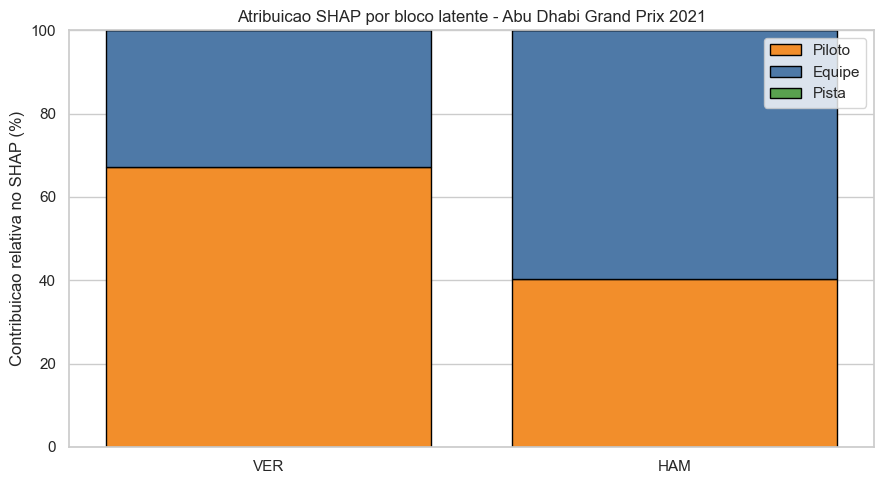

In [5]:
mappings = load_mappings(ANALYSIS_YEAR)
df_instances = load_instances()
race_name = get_race_name(mappings, ANALYSIS_ROUND)

primary_model_name = "model_orthogonal" if "model_orthogonal" in available_model_names else available_model_names[0]
primary_model = load_model(primary_model_name, results_map[primary_model_name].get("configuration", {}))
test_loader, graph_data = get_graph_and_test_loader()

driver_a_abbr, driver_b_abbr = DUEL_DRIVERS
driver_a_id = get_driver_id(mappings, driver_a_abbr)
driver_b_id = get_driver_id(mappings, driver_b_abbr)

driver_a_row, race_df = get_instance_row(df_instances, ANALYSIS_YEAR, ANALYSIS_ROUND, driver_a_id)
driver_b_row, _ = get_instance_row(df_instances, ANALYSIS_YEAR, ANALYSIS_ROUND, driver_b_id)


def build_background_fused(model, test_loader, graph_data, max_samples=BACKGROUND_SIZE):
    background_list = []
    collected = 0
    with torch.no_grad():
        for batch in test_loader:
            x_driver, x_track, c_ids, _ = [b.to(device) for b in batch]
            v_fused = get_fused_vector(model, x_driver, x_track, c_ids, graph_data)
            arr = v_fused.detach().cpu().numpy()
            background_list.append(arr)
            collected += arr.shape[0]
            if collected >= max_samples:
                break

    bg = np.concatenate(background_list, axis=0)
    return bg[:max_samples]


def explain_rows_with_shap(model, rows, test_loader, graph_data):
    fused_instances = []
    for row in rows:
        x_d, x_t, c_id = get_instance_tensors(row)
        fused_instances.append(get_fused_vector(model, x_d, x_t, c_id, graph_data).detach().cpu().numpy())

    x_eval = np.concatenate(fused_instances, axis=0)
    background = build_background_fused(model, test_loader, graph_data, max_samples=BACKGROUND_SIZE)
    explainer = shap.KernelExplainer(model_prediction_fn(model), background)
    shap_values = explainer.shap_values(x_eval)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    return x_eval, shap_values


_, duel_shap_values = explain_rows_with_shap(
    primary_model,
    [driver_a_row, driver_b_row],
    test_loader,
    graph_data,
)

duel_rows = []
for abbr, row, shap_vec in [
    (driver_a_abbr, driver_a_row, duel_shap_values[0]),
    (driver_b_abbr, driver_b_row, duel_shap_values[1]),
]:
    summary = summarize_block_impacts(shap_vec, primary_model)
    summary.update(
        {
            "driver_abbr": abbr,
            "driver_name": get_driver_name(mappings, abbr),
            "driver_id": int(row["driverId"]),
            "constructor_id": int(row["constructorId"]),
            "pred_prob_top3": forward_probability(
                primary_model,
                *get_instance_tensors(row),
                graph_data,
            ),
        }
    )
    duel_rows.append(summary)

duel_df = pd.DataFrame(duel_rows)
print(f"Duelo SHAP: {race_name} {ANALYSIS_YEAR} (round {ANALYSIS_ROUND})")
display(duel_df)

labels = duel_df["driver_abbr"].tolist()
pilot_vals = duel_df["pilot_share"].values
team_vals = duel_df["team_share"].values
track_vals = duel_df["track_share"].values

plt.figure(figsize=(9, 5))
plt.bar(labels, pilot_vals, label="Piloto", edgecolor="black", color="#f28e2b")
plt.bar(labels, team_vals, bottom=pilot_vals, label="Equipe", edgecolor="black", color="#4e79a7")
plt.bar(labels, track_vals, bottom=pilot_vals + team_vals, label="Pista", edgecolor="black", color="#59a14f")
plt.ylabel("Contribuicao relativa no SHAP (%)")
plt.title(f"Atribuicao SHAP por bloco latente - {race_name} {ANALYSIS_YEAR}")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4) Temporada Completa 2021: Habilidade vs Dependencia da Equipe

Nesta etapa calculamos SHAP para **todos os pilotos em todas as corridas de 2021**, gerando:

- indice de habilidade (`skill_index = pilot_share`);
- indice de dependencia de equipe (`team_dependency_index = team_share`);
- ranking agregado da temporada;
- curva corrida-a-corrida para MAX e LEWIS.

100%|██████████| 437/437 [01:56<00:00,  3.75it/s]


Tabelona - Importancias agregadas por piloto (temporada 2021)


,driver_abbr,driver_name,races,mean_skill_index,median_skill_index,std_skill_index,p95_skill_index,mean_team_dependency,median_team_dependency,std_team_dependency,p95_team_dependency,mean_pred_prob_top3
0,VER,Max Verstappen,22,66.608595,67.041154,1.652576,68.114863,33.391405,32.958846,1.652576,37.154334,0.555377
1,GIO,Antonio Giovinazzi,22,42.517203,42.549042,0.711582,43.791031,57.482797,57.450958,0.711582,58.258129,0.013763
2,KUB,Robert Kubica,2,41.966305,41.966305,0.315418,42.167036,58.033695,58.033695,0.315418,58.234426,0.013871
3,MAZ,Nikita Mazepin,21,41.455556,41.518359,0.669108,42.495154,58.544444,58.481641,0.669108,59.507116,0.014098
4,RAI,Kimi RÃ¤ikkÃ¶nen,20,41.432425,41.450067,0.760615,42.374274,58.567575,58.549933,0.760615,59.529543,0.015130
5,RUS,George Russell,22,41.329439,41.435871,0.907955,42.635399,58.670561,58.564129,0.907955,59.925201,0.014259
6,MSC,Mick Schumacher,21,41.075445,40.820580,0.730847,42.342765,58.924555,59.179420,0.730847,59.870907,0.014106
7,LAT,Nicholas Latifi,22,41.026765,41.327828,0.781460,41.910188,58.973235,58.672172,0.781460,60.301624,0.014535
8,HAM,Lewis Hamilton,22,40.295299,40.534676,1.216574,41.672053,59.704701,59.465324,1.216574,61.274979,0.713906
9,STR,Lance Stroll,22,40.011710,41.073437,3.301628,42.531316,59.951299,58.780285,3.310080,68.325680,0.016232


Top 10 por habilidade media (skill_index)


,driver_abbr,driver_name,mean_skill_index,mean_team_dependency
0,VER,Max Verstappen,66.608595,33.391405
1,GIO,Antonio Giovinazzi,42.517203,57.482797
2,KUB,Robert Kubica,41.966305,58.033695
3,MAZ,Nikita Mazepin,41.455556,58.544444
4,RAI,Kimi RÃ¤ikkÃ¶nen,41.432425,58.567575
5,RUS,George Russell,41.329439,58.670561
6,MSC,Mick Schumacher,41.075445,58.924555
7,LAT,Nicholas Latifi,41.026765,58.973235
8,HAM,Lewis Hamilton,40.295299,59.704701
9,STR,Lance Stroll,40.011710,59.951299


Top 10 mais dependentes da equipe


,driver_abbr,driver_name,mean_team_dependency,mean_skill_index
20,SAI,Carlos Sainz,77.051492,22.948508
19,BOT,Valtteri Bottas,74.917770,25.082230
18,NOR,Lando Norris,71.837759,28.162241
17,RIC,Daniel Ricciardo,71.749114,28.250886
16,LEC,Charles Leclerc,67.263803,32.656363
15,GAS,Pierre Gasly,64.674502,35.325498
14,OCO,Esteban Ocon,62.480820,37.519180
13,VET,Sebastian Vettel,61.881092,38.058542
12,TSU,Yuki Tsunoda,61.126142,38.873858
11,ALO,Fernando Alonso,60.900329,39.099671


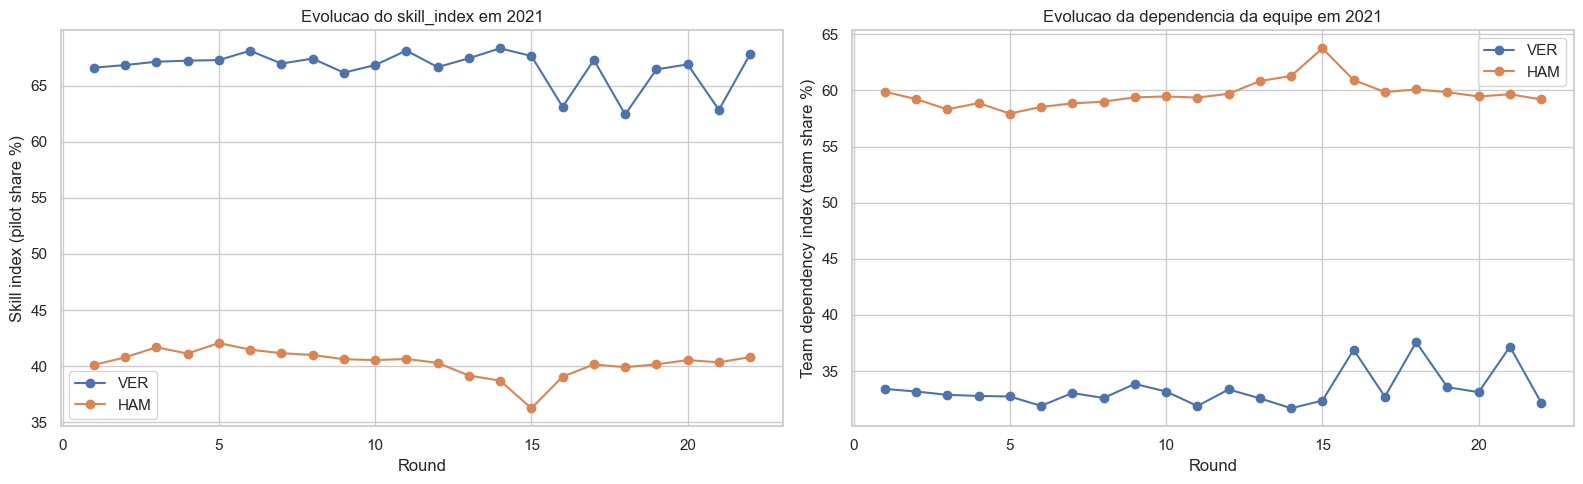

In [6]:
season_df = df_instances[df_instances["year"] == ANALYSIS_YEAR].copy()
season_df = season_df.sort_values(["round", "driverId"]).reset_index(drop=True)

# Calcula vetores fundidos para toda temporada de uma vez
fused_list = []
season_rows = []
with torch.no_grad():
    for _, row in season_df.iterrows():
        x_d, x_t, c_id = get_instance_tensors(row)
        fused = get_fused_vector(primary_model, x_d, x_t, c_id, graph_data)
        fused_list.append(fused.detach().cpu().numpy())
        season_rows.append(row)

season_fused = np.concatenate(fused_list, axis=0)
background = build_background_fused(primary_model, test_loader, graph_data, max_samples=BACKGROUND_SIZE)
season_explainer = shap.KernelExplainer(model_prediction_fn(primary_model), background)
season_shap = season_explainer.shap_values(season_fused)
if isinstance(season_shap, list):
    season_shap = season_shap[0]

season_records = []
for idx, (_, row) in enumerate(season_df.iterrows()):
    block = summarize_block_impacts(season_shap[idx], primary_model)
    driver_id = int(row["driverId"])

    # Resolve abreviacao pelo mapeamento
    driver_abbr = None
    for abbr, info in mappings["drivers"].items():
        if int(info["driver_id"]) == driver_id:
            driver_abbr = abbr
            break
    if driver_abbr is None:
        driver_abbr = str(driver_id)

    season_records.append(
        {
            "year": int(row["year"]),
            "round": int(row["round"]),
            "raceId": int(row["raceId"]),
            "driver_id": driver_id,
            "driver_abbr": driver_abbr,
            "driver_name": get_driver_name(mappings, driver_abbr) if driver_abbr in mappings["drivers"] else str(driver_id),
            "constructor_id": int(row["constructorId"]),
            "top3": int(row["top3"]),
            "pred_prob_top3": forward_probability(primary_model, *get_instance_tensors(row), graph_data),
            "pilot_share": block["pilot_share"],
            "team_share": block["team_share"],
            "track_share": block["track_share"],
            "pilot_abs": block["pilot_abs"],
            "team_abs": block["team_abs"],
            "track_abs": block["track_abs"],
            "skill_index": block["pilot_share"],
            "team_dependency_index": block["team_share"],
        }
    )

season_shap_df = pd.DataFrame(season_records)

summary_table = (
    season_shap_df.groupby(["driver_abbr", "driver_name"], as_index=False)
    .agg(
        races=("round", "count"),
        mean_skill_index=("skill_index", "mean"),
        median_skill_index=("skill_index", "median"),
        std_skill_index=("skill_index", "std"),
        p95_skill_index=("skill_index", lambda s: np.quantile(s, 0.95)),
        mean_team_dependency=("team_dependency_index", "mean"),
        median_team_dependency=("team_dependency_index", "median"),
        std_team_dependency=("team_dependency_index", "std"),
        p95_team_dependency=("team_dependency_index", lambda s: np.quantile(s, 0.95)),
        mean_pred_prob_top3=("pred_prob_top3", "mean"),
    )
)

summary_table = summary_table.sort_values("mean_skill_index", ascending=False).reset_index(drop=True)

print("Tabelona - Importancias agregadas por piloto (temporada 2021)")
display(summary_table)

print("Top 10 por habilidade media (skill_index)")
display(summary_table[["driver_abbr", "driver_name", "mean_skill_index", "mean_team_dependency"]].head(10))

print("Top 10 mais dependentes da equipe")
display(summary_table.sort_values("mean_team_dependency", ascending=False)[["driver_abbr", "driver_name", "mean_team_dependency", "mean_skill_index"]].head(10))

comparison_abbrs = ["VER", "HAM"]
line_df = season_shap_df[season_shap_df["driver_abbr"].isin(comparison_abbrs)].copy()
line_df = line_df.sort_values(["driver_abbr", "round"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
for abbr in comparison_abbrs:
    tmp = line_df[line_df["driver_abbr"] == abbr]
    axes[0].plot(tmp["round"], tmp["skill_index"], marker="o", label=abbr)
    axes[1].plot(tmp["round"], tmp["team_dependency_index"], marker="o", label=abbr)

axes[0].set_title("Evolucao do skill_index em 2021")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Skill index (pilot share %)")
axes[0].legend()

axes[1].set_title("Evolucao da dependencia da equipe em 2021")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Team dependency index (team share %)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5) Contrafactual: RUSSELL no lugar de BOTTAS em 2021

A pergunta aqui e: mantendo o **contexto de corrida e equipe da Mercedes**, o que aconteceria com a probabilidade predita de `top3` se trocarmos os atributos do piloto de BOTTAS para RUSSELL?

Metodo por corrida:

- baseline: `BOTTAS@Mercedes` na corrida real;
- contrafactual: `features(RUSSELL na mesma corrida)` + `constructorId(Mercedes)`;
- comparar `Delta = P(top3)_RussellMercedes - P(top3)_BottasMercedes`.

Comparacao contrafactual por corrida (RUSSELL no lugar de BOTTAS)


,year,round,race_name,bot_constructor_id,rus_real_constructor_id,prob_top3_bot_real,prob_top3_rus_as_bot,delta_prob,bot_top3_real
0,2021,1,Bahrain Grand Prix,129,2,0.696979,0.248737,-0.448242,1
1,2021,2,Emilia Romagna Grand Prix,129,2,0.702017,0.249490,-0.452527,0
2,2021,3,Portuguese Grand Prix,129,2,0.686928,0.250653,-0.436275,1
3,2021,4,Spanish Grand Prix,129,2,0.652980,0.250003,-0.402976,1
4,2021,5,Monaco Grand Prix,129,2,0.658371,0.248663,-0.409708,0
5,2021,6,Azerbaijan Grand Prix,129,2,0.629616,0.248716,-0.380900,0
6,2021,7,French Grand Prix,129,2,0.521656,0.250174,-0.271482,0
7,2021,8,Styrian Grand Prix,129,2,0.581353,0.251414,-0.329940,1
8,2021,9,Austrian Grand Prix,129,2,0.635190,0.252154,-0.383036,1
9,2021,10,British Grand Prix,129,2,0.679270,0.247035,-0.432234,1


Resumo agregado do contrafactual:


,mean_delta_prob,median_delta_prob,pct_rounds_improves,pct_rounds_worsens
0,-0.371029,-0.381968,0.0,100.0


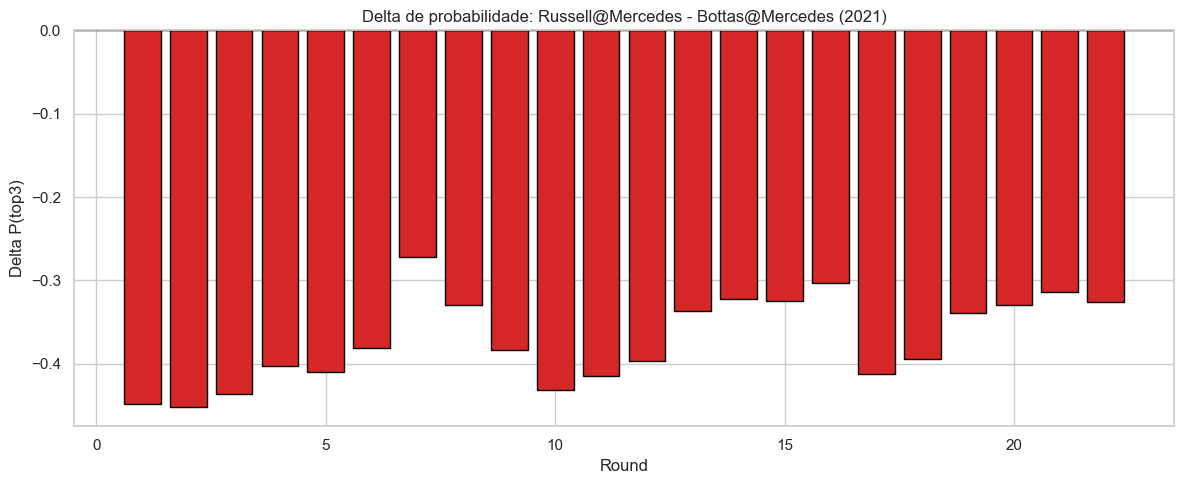

In [7]:
bot_abbr, rus_abbr = COUNTERFACTUAL_DRIVERS
bot_id = get_driver_id(mappings, bot_abbr)
rus_id = get_driver_id(mappings, rus_abbr)

counterfactual_rows = []

for round_id in sorted(season_df["round"].unique()):
    race_slice = season_df[season_df["round"] == round_id]

    bot_slice = race_slice[race_slice["driverId"] == bot_id]
    rus_slice = race_slice[race_slice["driverId"] == rus_id]

    if bot_slice.empty or rus_slice.empty:
        continue

    bot_row = bot_slice.iloc[0]
    rus_row = rus_slice.iloc[0]

    # Baseline real: Bottas no contexto real da corrida
    bot_xd, bot_xt, bot_cid = get_instance_tensors(bot_row)
    prob_bot = forward_probability(primary_model, bot_xd, bot_xt, bot_cid, graph_data)

    # Contrafactual: features de Russell + mesma pista e mesma equipe da linha do Bottas
    rus_xd = torch.tensor(rus_row[DRIVER_FEATURES].astype(float).values, dtype=torch.float32).unsqueeze(0).to(device)
    same_track_xt = bot_xt
    same_team_cid = torch.tensor([int(bot_row["constructorId"])], dtype=torch.long).to(device)
    prob_rus_counterfactual = forward_probability(primary_model, rus_xd, same_track_xt, same_team_cid, graph_data)

    counterfactual_rows.append(
        {
            "year": ANALYSIS_YEAR,
            "round": int(round_id),
            "race_name": get_race_name(mappings, round_id),
            "bot_constructor_id": int(bot_row["constructorId"]),
            "rus_real_constructor_id": int(rus_row["constructorId"]),
            "prob_top3_bot_real": prob_bot,
            "prob_top3_rus_as_bot": prob_rus_counterfactual,
            "delta_prob": prob_rus_counterfactual - prob_bot,
            "bot_top3_real": int(bot_row["top3"]),
        }
    )

counterfactual_df = pd.DataFrame(counterfactual_rows).sort_values("round")

print("Comparacao contrafactual por corrida (RUSSELL no lugar de BOTTAS)")
display(counterfactual_df)

if not counterfactual_df.empty:
    agg = {
        "mean_delta_prob": counterfactual_df["delta_prob"].mean(),
        "median_delta_prob": counterfactual_df["delta_prob"].median(),
        "pct_rounds_improves": 100.0 * (counterfactual_df["delta_prob"] > 0).mean(),
        "pct_rounds_worsens": 100.0 * (counterfactual_df["delta_prob"] < 0).mean(),
    }

    print("Resumo agregado do contrafactual:")
    display(pd.DataFrame([agg]))

    plt.figure(figsize=(12, 5))
    colors = ["#2ca02c" if x > 0 else "#d62728" for x in counterfactual_df["delta_prob"]]
    plt.bar(counterfactual_df["round"], counterfactual_df["delta_prob"], color=colors, edgecolor="black")
    plt.axhline(0.0, color="black", linewidth=1)
    plt.title("Delta de probabilidade: Russell@Mercedes - Bottas@Mercedes (2021)")
    plt.xlabel("Round")
    plt.ylabel("Delta P(top3)")
    plt.tight_layout()
    plt.show()

## 6) Aplicacao Pratica: Motor de Decisao para Line-up Piloto-Equipe

Aplicacao proposta: para uma corrida alvo, simular combinacoes de pilotos com uma equipe fixa e gerar um **shortlist** dos pilotos com maior probabilidade de `top3`.

Exemplo implementado:

- equipe alvo: Mercedes (a partir do contexto de BOTTAS na corrida selecionada);
- corrida alvo: Abu Dhabi 2021 (parametrizavel);
- pilotos candidatos: todos os pilotos com linha disponivel na corrida.

Esse modulo pode ser reutilizado no planejamento pre-corrida para avaliar trocas de lineup ou risco de desempenho.

Shortlist de pilotos para a equipe alvo na corrida selecionada


,year,round,race_name,target_team_id,driver_abbr,driver_name,sim_prob_top3
0,2021,22,Abu Dhabi Grand Prix,129,VER,Max Verstappen,0.716713
1,2021,22,Abu Dhabi Grand Prix,129,HAM,Lewis Hamilton,0.714713
2,2021,22,Abu Dhabi Grand Prix,129,LEC,Charles Leclerc,0.613872
3,2021,22,Abu Dhabi Grand Prix,129,BOT,Valtteri Bottas,0.576797
4,2021,22,Abu Dhabi Grand Prix,129,PER,Sergio Perez,0.443606
5,2021,22,Abu Dhabi Grand Prix,129,GAS,Pierre Gasly,0.423415
6,2021,22,Abu Dhabi Grand Prix,129,SAI,Carlos Sainz,0.369520
7,2021,22,Abu Dhabi Grand Prix,129,RIC,Daniel Ricciardo,0.364068
8,2021,22,Abu Dhabi Grand Prix,129,NOR,Lando Norris,0.313351
9,2021,22,Abu Dhabi Grand Prix,129,ALO,Fernando Alonso,0.296273


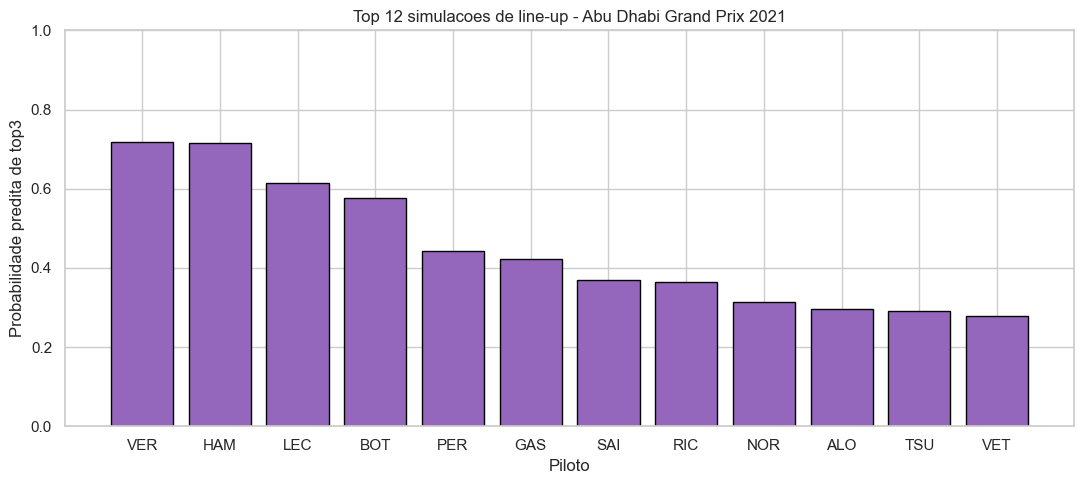

In [8]:
target_round = ANALYSIS_ROUND
race_slice = season_df[season_df["round"] == target_round].copy()

if race_slice.empty:
    raise ValueError(f"Nenhum dado encontrado para round={target_round} em {ANALYSIS_YEAR}")

# Equipe base da simulacao: mesma equipe do Bottas nessa corrida
bot_target_row = race_slice[race_slice["driverId"] == bot_id]
if bot_target_row.empty:
    raise ValueError("Nao foi possivel encontrar Bottas na corrida alvo para definir equipe base")

team_id_for_sim = int(bot_target_row.iloc[0]["constructorId"])

sim_records = []
for _, row in race_slice.iterrows():
    driver_id = int(row["driverId"])

    # Busca abreviacao
    driver_abbr = None
    for abbr, info in mappings["drivers"].items():
        if int(info["driver_id"]) == driver_id:
            driver_abbr = abbr
            break
    if driver_abbr is None:
        driver_abbr = str(driver_id)

    x_d = torch.tensor(row[DRIVER_FEATURES].astype(float).values, dtype=torch.float32).unsqueeze(0).to(device)
    x_t = torch.tensor(row[TRACK_FEATURES].astype(float).values, dtype=torch.float32).unsqueeze(0).to(device)
    c_id = torch.tensor([team_id_for_sim], dtype=torch.long).to(device)

    prob_sim = forward_probability(primary_model, x_d, x_t, c_id, graph_data)

    sim_records.append(
        {
            "year": ANALYSIS_YEAR,
            "round": int(target_round),
            "race_name": get_race_name(mappings, target_round),
            "target_team_id": team_id_for_sim,
            "driver_abbr": driver_abbr,
            "driver_name": get_driver_name(mappings, driver_abbr) if driver_abbr in mappings["drivers"] else str(driver_id),
            "sim_prob_top3": prob_sim,
        }
    )

lineup_df = pd.DataFrame(sim_records).sort_values("sim_prob_top3", ascending=False).reset_index(drop=True)

print("Shortlist de pilotos para a equipe alvo na corrida selecionada")
display(lineup_df.head(10))

plt.figure(figsize=(11, 5))
show_n = min(12, len(lineup_df))
plot_df = lineup_df.head(show_n)
plt.bar(plot_df["driver_abbr"], plot_df["sim_prob_top3"], color="#9467bd", edgecolor="black")
plt.title(f"Top {show_n} simulacoes de line-up - {get_race_name(mappings, target_round)} {ANALYSIS_YEAR}")
plt.xlabel("Piloto")
plt.ylabel("Probabilidade predita de top3")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 7) Leituras Finais e Proximos Passos

Sugestoes para extensao imediata:

1. Repetir toda a analise para outros anos (`ANALYSIS_YEAR`) e verificar estabilidade dos indices.
2. Salvar `season_shap_df`, `summary_table` e `counterfactual_df` em CSV para relatorio externo.
3. Rodar o mesmo estudo para outros pares de pilotos rivais e outras equipes.
4. Testar cenarios de combinacoes piloto-equipe para corridas futuras usando features atualizadas.

Com isso, o framework deixa de ser apenas um classificador e passa a servir como ferramenta de diagnostico e apoio a decisao esportiva.